# 04 - Metaparameters: Activation Functions, Optimizers, and LR Schedulers

This notebook investigates critical hyperparameter choices in neural networks:

1. **Activation Functions**: Sigmoid, Tanh, ReLU, LeakyReLU, ELU, GELU, Softmax.
2. **Vanishing Gradient Problem**: Empirical demonstration with deep Sigmoid vs ReLU networks.
3. **Optimizers**: SGD, SGD + Momentum, RMSprop, Adam, AdamW.
4. **Learning Rate Schedulers**: `StepLR`, `ReduceLROnPlateau`, `CosineAnnealingLR`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as torch_optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Mathematical Visualization of Activation Functions & Derivatives

Activation functions introduce non-linearity into neural networks. Here we plot 6 popular activation functions along with their analytical first derivatives.


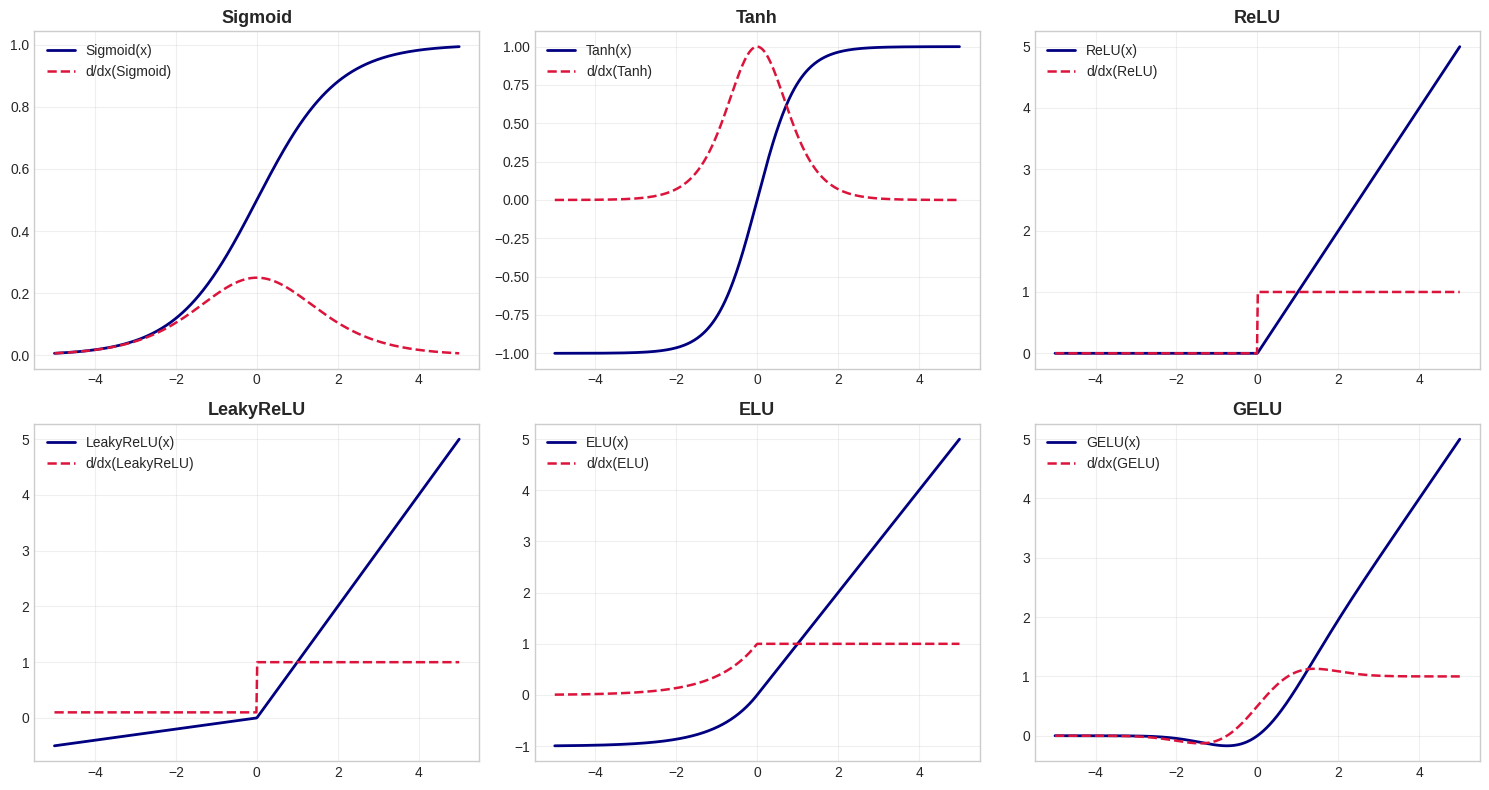

In [3]:
x = torch.linspace(-5, 5, 500, requires_grad=True)

activations = {
    'Sigmoid': torch.sigmoid(x),
    'Tanh': torch.tanh(x),
    'ReLU': F.relu(x),
    'LeakyReLU': F.leaky_relu(x, negative_slope=0.1),
    'ELU': F.elu(x, alpha=1.0),
    'GELU': F.gelu(x)
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, act) in enumerate(activations.items()):
    # Compute derivative via autograd
    if x.grad is not None:
        x.grad.zero_()
    act.sum().backward(retain_graph=True)
    grad = x.grad.clone()
    
    axes[i].plot(x.detach().numpy(), act.detach().numpy(), label=f'{name}(x)', color='navy', linewidth=2)
    axes[i].plot(x.detach().numpy(), grad.numpy(), label=f"d/dx({name})", color='crimson', linestyle='--', linewidth=1.8)
    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Vanishing Gradient Experiment: Deep Sigmoid vs ReLU / GELU

When networks grow deep (e.g. 6+ layers), Sigmoid activations saturate near 0 or 1 where their derivative $\approx 0$. This causes gradients to exponentially decay toward the input layer, preventing learning (**Vanishing Gradient Problem**).


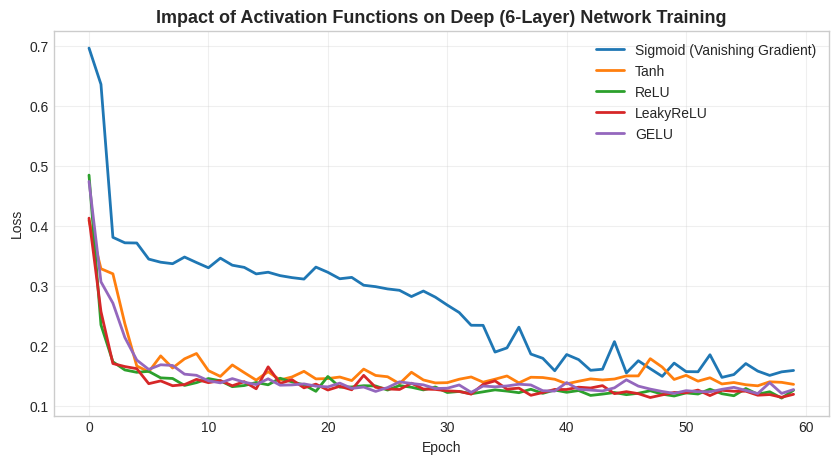

In [4]:
X_m, y_m = make_moons(n_samples=1000, noise=0.25, random_state=42)
scaler = StandardScaler()
X_m_s = scaler.fit_transform(X_m)

X_t = torch.tensor(X_m_s, dtype=torch.float32)
y_t = torch.tensor(y_m, dtype=torch.long)
loader = DataLoader(TensorDataset(X_t, y_t), batch_size=32, shuffle=True)

# Helper function to construct a deep 6-layer ANN with chosen activation
def build_deep_net(activation_class):
    layers = []
    dims = [2, 64, 64, 64, 64, 64, 2]
    for i in range(len(dims) - 2):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        layers.append(activation_class())
    layers.append(nn.Linear(dims[-2], dims[-1]))
    return nn.Sequential(*layers)

act_candidates = {
    'Sigmoid (Vanishing Gradient)': nn.Sigmoid,
    'Tanh': nn.Tanh,
    'ReLU': nn.ReLU,
    'LeakyReLU': lambda: nn.LeakyReLU(0.1),
    'GELU': nn.GELU
}

histories_act = {}

for name, act_cls in act_candidates.items():
    model = build_deep_net(act_cls)
    optimizer = torch_optim.Adam(model.parameters(), lr=0.003)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    for epoch in range(60):
        running_loss = 0.0
        for bx, by in loader:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(by)
        losses.append(running_loss / len(X_t))
    histories_act[name] = losses

# Plot activation training comparison
plt.figure(figsize=(10, 5))
for name, losses in histories_act.items():
    plt.plot(losses, label=name, linewidth=2)
plt.title('Impact of Activation Functions on Deep (6-Layer) Network Training', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Optimizer Deep-Dive: Comparing Convergence Behaviors

We compare 5 optimization algorithms on an identical 3-layer architecture:

- **SGD**: Basic gradient update $w \leftarrow w - \eta \nabla L$.
- **SGD + Momentum**: Uses velocity history to accelerate through flat regions.
- **RMSprop**: Scales learning rate by running average of squared gradients.
- **Adam**: Combines momentum and adaptive learning rates.
- **AdamW**: Adam with decoupled weight decay.


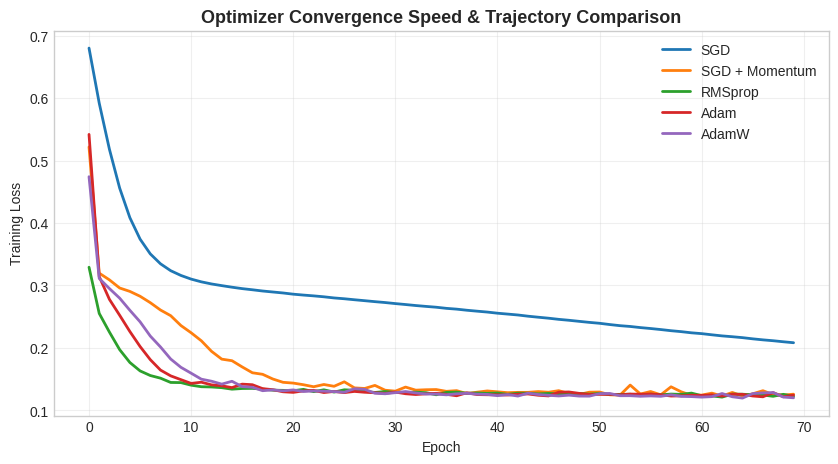

In [5]:
def build_standard_net():
    return nn.Sequential(
        nn.Linear(2, 64),
        nn.ReLU(),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Linear(64, 2)
    )

opt_dict = {
    'SGD': lambda params: torch_optim.SGD(params, lr=0.01),
    'SGD + Momentum': lambda params: torch_optim.SGD(params, lr=0.01, momentum=0.9),
    'RMSprop': lambda params: torch_optim.RMSprop(params, lr=0.001),
    'Adam': lambda params: torch_optim.Adam(params, lr=0.001),
    'AdamW': lambda params: torch_optim.AdamW(params, lr=0.001, weight_decay=1e-3)
}

histories_opt = {}

for name, opt_fn in opt_dict.items():
    model = build_standard_net()
    optimizer = opt_fn(model.parameters())
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    for epoch in range(70):
        running_loss = 0.0
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(by)
        losses.append(running_loss / len(X_t))
    histories_opt[name] = losses

plt.figure(figsize=(10, 5))
for name, losses in histories_opt.items():
    plt.plot(losses, label=name, linewidth=2)
plt.title('Optimizer Convergence Speed & Trajectory Comparison', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 4. Learning Rate Schedulers

Dynamic learning rate adjustment improves convergence fine-tuning:

1. `StepLR`: Multiplies LR by $\gamma$ every `step_size` epochs.
2. `CosineAnnealingLR`: Decays LR continuously following a cosine wave.


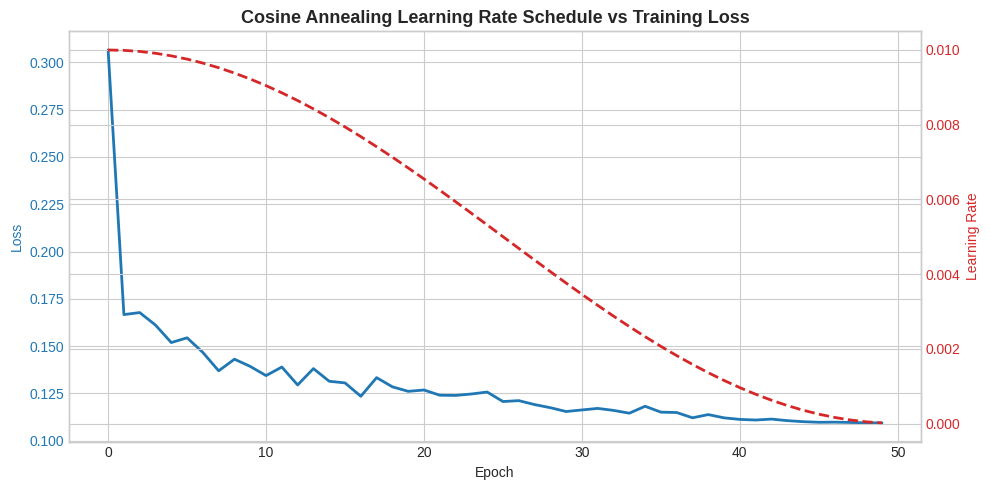

In [6]:
model_sched = build_standard_net()
optimizer = torch_optim.Adam(model_sched.parameters(), lr=0.01)
scheduler = torch_optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

lrs = []
losses = []
criterion = nn.CrossEntropyLoss()

for epoch in range(50):
    running_loss = 0.0
    for bx, by in loader:
        optimizer.zero_grad()
        loss = criterion(model_sched(bx), by)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(by)
        
    lrs.append(scheduler.get_last_lr()[0])
    losses.append(running_loss / len(X_t))
    scheduler.step()

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(losses, color=color, linewidth=2, label='Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Learning Rate', color=color)
ax2.plot(lrs, color=color, linewidth=2, linestyle='--', label='Cosine LR Schedule')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Cosine Annealing Learning Rate Schedule vs Training Loss', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()
